# La rete si fa profonda

*Abbiamo costruito il primo neurone artificiale e visto che riesce a distinguere riposo da movimento quasi perfettamente. Ma il braccialetto WristMind deve fare di più: deve riconoscere **sei attività diverse** e un neurone solo non ce la fa. Abbiamo bisogno di qualcosa di più potente.*

**Il problema**

*La frontiera che separa "salire le scale" da "camminare in piano" non è una linea retta. I segnali del giroscopio e dell'accelerometro si mescolano in modo complesso. Per catturare queste relazioni non-lineari, dobbiamo impilare più neuroni in strati successivi: una **rete neurale profonda**.*

In [1]:
# Ricarichiamo tutto come nel notebook precedente
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras

np.random.seed(42)
tf.random.set_seed(42)

print("Carico il dataset HAR...")
har = fetch_openml(data_id=1478, as_frame=True, parser='auto')
X = har.data.astype(np.float32)
y = har.target.astype(int)

nomi_attivita = {1:"Camminare",2:"Salire scale",3:"Scendere scale",
                 4:"Seduto",5:"In piedi",6:"Sdraiato"}

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Etichette 0-based per Keras (0..5 invece di 1..6)
y_train_0 = y_train - 1
y_test_0  = y_test  - 1

print(f"Training set: {X_train_sc.shape[0]} campioni")
print(f"Test set:     {X_test_sc.shape[0]} campioni")

Carico il dataset HAR...
Training set: 7724 campioni
Test set:     2575 campioni


## Perché un solo strato non basta

Immaginate di voler separare sei gruppi di punti su un piano. Se i gruppi sono separati da linee rette, un classificatore lineare funziona. Ma se i gruppi si *intrecciano* in modo curvo, una linea retta non basta: servono curve più elaborate.

Nelle reti neurali, la capacità di tracciare frontiere curve si ottiene **impilando più strati di neuroni**. Ogni strato applica la propria combinazione non-lineare all'output del precedente. Il risultato è una trasformazione dello spazio degli input che può rendere separabili classi che prima non lo erano.

Esiste un risultato matematico noto come **Teorema di Approssimazione Universale**: una rete con almeno uno strato nascosto sufficientemente grande può approssimare *qualsiasi funzione continua*. Non è una garanzia pratica (servono dati e tempo per imparare), ma il teorema ci garantisce che l'architettura è fondamentalmente capace.

## Architettura di una rete multi-strato

Una **rete neurale densa** (o Multi-Layer Perceptron, MLP) è organizzata in strati:

1. **Strato di ingresso** (*input layer*): non fa calcoli, riceve i dati grezzi. Nel nostro caso, 561 valori di feature.

2. **Strati nascosti** (*hidden layers*): strati intermedi dove avviene la "magia". Ogni neurone riceve tutti gli output dello strato precedente, li combina con i propri pesi e produce un'uscita.

3. **Strato di uscita** (*output layer*): produce la previsione finale. Per 6 classi, 6 neuroni con attivazione **softmax**.

La softmax è la funzione di attivazione giusta per la classificazione multiclasse:

$$\text{softmax}(z_k) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

Trasforma $K$ numeri reali in $K$ probabilità che sommano a 1. Il neurone con la probabilità più alta indica la classe predetta.

Nell'addestramento usiamo la funzione costo **cross-entropy categoriale**:

$$\mathcal{L} = -\sum_{k=1}^{K} y_k \log(\hat{p}_k)$$

che misura quanto la distribuzione prevista $\hat{p}$ si discosta dall'etichetta vera $y$ (che vale 1 solo per la classe corretta).

In [2]:
# Costruiamo una rete con due strati nascosti
# Architettura: 561 input -> 128 neuroni -> 64 neuroni -> 6 output

modello_mlp = keras.Sequential([
    # Primo strato nascosto: 128 neuroni con ReLU
    # ReLU e' la funzione di attivazione piu' usata negli strati nascosti:
    # è semplice, rapida da calcolare, e funziona bene in pratica
    keras.layers.Dense(128, activation='relu', input_shape=(X_train_sc.shape[1],)),

    # Secondo strato nascosto: 64 neuroni con ReLU
    # Riduciamo progressivamente il numero di neuroni: la rete impara
    # rappresentazioni sempre più astratte e compatte
    keras.layers.Dense(64, activation='relu'),

    # Strato di uscita: 6 neuroni (uno per attivita') con softmax
    # L'output è un vettore di 6 probabilita' che sommano a 1
    keras.layers.Dense(6, activation='softmax')
], name="rete_profonda")

# sparse_categorical_crossentropy: come categorical_crossentropy ma le etichette
# sono interi (0..5) invece di vettori one-hot
modello_mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modello_mlp.summary()

Model: "rete_profonda"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        71,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,582 (314.77 KB)

 Trainable params: 80,582 (314.77 KB)

 Non-trainable params: 0 (0.00 B)

Il riepilogo mostra il numero di **parametri addestrabili**: per ogni strato, è il prodotto tra ingressi e uscite più i bias. Sono tutti i pesi che la discesa del gradiente deve ottimizzare durante il training.

Notiamo che i numeri sono molto più grandi del singolo neurone (562 parametri). Più parametri = più capacità di rappresentare relazioni complesse, ma anche più rischio di overfitting e più tempo di training. Il bilanciamento bias-varianza che abbiamo imparato nella lezione 2 vale anche qui.

In [3]:
# Addestriamo la rete multi-strato
# Usiamo piu' epoch perche' la rete ha piu' parametri da ottimizzare
storia_mlp = modello_mlp.fit(
    X_train_sc, y_train_0,
    epochs=50,
    batch_size=64,        # quanti campioni per ogni aggiornamento dei pesi
    validation_split=0.2, # 20% del training per il monitoraggio
    verbose=0
)

loss_mlp, acc_mlp = modello_mlp.evaluate(X_test_sc, y_test_0, verbose=0)
print(f"Accuratezza sul test set: {acc_mlp:.1%}")

Accuratezza sul test set: 98.3%


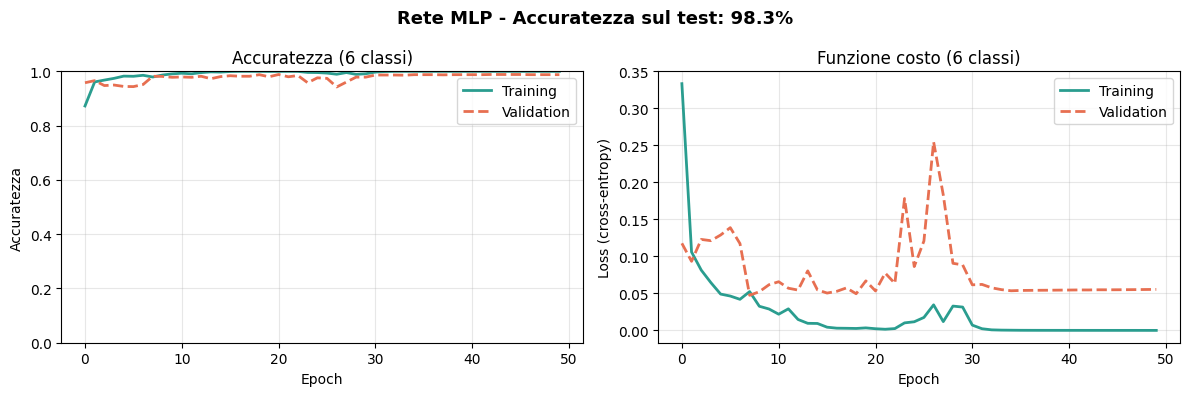

In [7]:
# Curve di apprendimento: come sta imparando la rete?
fig, assi = plt.subplots(1, 2, figsize=(12, 4))

assi[0].plot(storia_mlp.history['accuracy'],
             label='Training', color='#2a9d8f', linewidth=2)
assi[0].plot(storia_mlp.history['val_accuracy'],
             label='Validation', color='#e76f51', linewidth=2, linestyle='--')
assi[0].set_title('Accuratezza (6 classi)')
assi[0].set_xlabel('Epoch')
assi[0].set_ylabel('Accuratezza')
assi[0].legend()
assi[0].grid(True, alpha=0.3)
assi[0].set_ylim([0, 1])

assi[1].plot(storia_mlp.history['loss'],
             label='Training', color='#2a9d8f', linewidth=2)
assi[1].plot(storia_mlp.history['val_loss'],
             label='Validation', color='#e76f51', linewidth=2, linestyle='--')
assi[1].set_title('Funzione costo (6 classi)')
assi[1].set_xlabel('Epoch')
assi[1].set_ylabel('Loss (cross-entropy)')
assi[1].legend()
assi[1].grid(True, alpha=0.3)

plt.suptitle(f'Rete MLP - Accuratezza sul test: {acc_mlp:.1%}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## La matrice di confusione

L'accuratezza globale è utile, ma non dice *dove* il modello sbaglia. Per questo esiste la **matrice di confusione**: una tabella $K \times K$ dove la riga indica la classe reale e la colonna la classe predetta. I valori sulla diagonale sono le predizioni corrette; gli altri sono gli errori.

Leggere la matrice di confusione ci aiuta a capire:
- Quali attività il modello confonde tra loro (es. salire scale vs. scendere scale)
- Se ci sono classi sistematicamente mal classificate
- Se alcuni errori sono "giustificabili" (es. confondere seduto e in piedi)

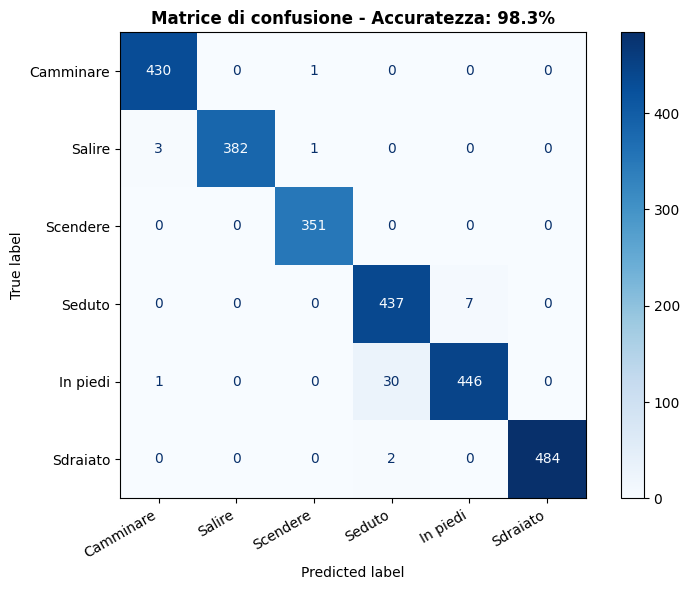


Errori più frequenti:
  Seduto       confusa con In piedi    : 7 volte
  In piedi     confusa con Seduto      : 30 volte


In [5]:
# Predizioni sul test set
y_pred_prob = modello_mlp.predict(X_test_sc, verbose=0)
# argmax: prende l'indice della probabilità massima tra i 6 valori
y_pred = np.argmax(y_pred_prob, axis=1)

# Matrice di confusione
nomi_brevi = ["Camminare", "Salire", "Scendere", "Seduto", "In piedi", "Sdraiato"]
cm = confusion_matrix(y_test_0, y_pred)

fig, asse = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomi_brevi)
disp.plot(ax=asse, colorbar=True, cmap='Blues')
plt.title(f'Matrice di confusione - Accuratezza: {acc_mlp:.1%}',
          fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Evidenziamo le classi più difficili
print("\nErrori più frequenti:")
for i in range(6):
    for j in range(6):
        if i != j and cm[i, j] > 5:
            print(f"  {nomi_brevi[i]:12s} confusa con {nomi_brevi[j]:12s}: {cm[i,j]} volte")

## Analizziamo gli errori

La matrice di confusione rivela qualcosa di interessante: i principali errori avvengono tra attività "fisicamente simili".

**Seduto e In piedi** sono le attività più spesso confuse tra loro: entrambe non producono quasi movimento nell'accelerometro. La differenza sta nella posizione del corpo, che i sensori al polso faticano a distinguere perfettamente.

**Salire e scendere le scale** a volte si confondono con il camminare in piano, perché tutti e tre producono movimenti ritmici simili al polso. Un sensore più ricco (ad esempio alla caviglia o all'anca) probabilmente farebbe meglio.

Questo ci insegna qualcosa di importante: le prestazioni di un modello dipendono non solo dall'algoritmo, ma anche dalla **qualità e posizione dei sensori**. Una scelta hardware intelligente può ridurre drammaticamente la difficoltà del problema. Il modello è solo una parte del sistema: i dati contano almeno quanto l'algoritmo.

## Confronto: singolo neurone vs. rete multi-strato

In [6]:
# Alleniamo anche il modello lineare (singolo strato) per confronto
modello_lineare = keras.Sequential([
    keras.layers.Dense(6, activation='softmax', input_shape=(X_train_sc.shape[1],))
], name="lineare")
modello_lineare.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])
modello_lineare.fit(X_train_sc, y_train_0, epochs=50,
                    batch_size=64, validation_split=0.2, verbose=0)
_, acc_lin = modello_lineare.evaluate(X_test_sc, y_test_0, verbose=0)

# Tabella di confronto
risultati = pd.DataFrame({
    "Modello": ["Lineare (senza strati nascosti)", "MLP (2 strati nascosti: 128+64)"],
    "Parametri": [
        modello_lineare.count_params(),
        modello_mlp.count_params()
    ],
    "Accuratezza test": [f"{acc_lin:.1%}", f"{acc_mlp:.1%}"]
})
print(risultati.to_string(index=False))

                        Modello  Parametri Accuratezza test
Lineare (senza strati nascosti)       3372            97.8%
MLP (2 strati nascosti: 128+64)      80582            98.3%


Il salto di prestazioni tra il modello lineare e la rete multi-strato è netto. Entrambi partono dagli stessi dati e usano lo stesso ottimizzatore; la differenza sta tutta nell'architettura. I due strati nascosti permettono alla rete di imparare rappresentazioni intermedie dei dati, qualcosa di simile a quello che fanno i neuroni nella corteccia visiva quando elaborano un'immagine a livelli progressivi di astrazione.

**Un'intuizione geometrica**: ogni strato nascosto "piega e deforma" lo spazio degli input. Dopo due strati di trasformazioni non lineari, le sei classi che prima erano sovrapposte nello spazio a 561 dimensioni diventano separabili linearmente. L'ultimo strato fa poi semplicemente la classificazione lineare in questo spazio trasformato.

## Come funziona la backpropagation

Fino ad ora abbiamo detto che Keras "ottimizza i pesi con la discesa del gradiente". Ma come si calcola il gradiente in una rete con centinaia di migliaia di parametri?

L'algoritmo si chiama **backpropagation** (retropropagazione dell'errore), ed è il motore che ha reso possibile il deep learning moderno.

L'idea è semplice:
1. **Forward pass**: i dati scorrono dall'input all'output attraverso tutti gli strati. Si calcola la previsione e l'errore.
2. **Backward pass**: l'errore scorre *al contrario*, dall'output all'input. Usando la **regola della catena** del calcolo differenziale, si calcola il gradiente dell'errore rispetto a ogni peso.
3. **Aggiornamento**: ogni peso viene aggiornato nella direzione che riduce l'errore (discesa del gradiente).

Questo ciclo si ripete per ogni batch di dati, per ogni epoch, finché i pesi convergono a valori che minimizzano l'errore.

$$w_j \leftarrow w_j - \eta \cdot \frac{\partial \mathcal{L}}{\partial w_j}$$

dove $\eta$ è il *learning rate* (già incontrato nella lezione 2) e $\frac{\partial \mathcal{L}}{\partial w_j}$ è il gradiente dell'errore rispetto al peso $w_j$.

---

> **Cosa abbiamo imparato**: Impilare neuroni in strati successivi sblocca una capacità che un neurone solo non ha: approssimare funzioni non lineari arbitrariamente complesse. Abbiamo costruito un Multi-Layer Perceptron con Keras, lo abbiamo addestrato su un problema a sei classi e letto la matrice di confusione per capire dove sbaglia. La backpropagation, il motore che permette l'apprendimento in reti profonde, non è altro che la discesa del gradiente applicata in modo intelligente usando la regola della catena.

> **Cosa faremo adesso?** Finora abbiamo usato la rete neurale solo per la classificazione. Nel prossimo notebook vedremo che la stessa architettura funziona anche per la **regressione** (prevedere un numero continuo). Poi sfideremo la nostra rete contro i modelli che conoscete già (k-NN e regressione lineare) per capire quando conviene usare una rete neurale e quando un modello più semplice è la scelta migliore.